In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('dataset/phishing_site_urls.csv')

In [4]:
df

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad
...,...,...
549341,23.227.196.215/,bad
549342,apple-checker.org/,bad
549343,apple-iclods.org/,bad
549344,apple-uptoday.org/,bad


In [5]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [6]:
df.shape

(549346, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [8]:
df.describe()

,URL,Label
count,549346,549346
unique,507195,2
top,jhomitevd2abj3fk.tor2web.org/,good
freq,52,392924


In [9]:
df.isnull().sum()

URL      0
Label    0
dtype: int64

In [10]:
df.Label.value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [11]:
from nltk.tokenize import RegexpTokenizer

In [12]:
tokenizer = RegexpTokenizer(r'[A-Z a-z]+')

In [13]:
df.URL[1]

'www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home-customer&nav=1/loading.php'

In [14]:
tokenizer.tokenize(df.URL[1])

['www',
 'dghjdgf',
 'com',
 'paypal',
 'co',
 'uk',
 'cycgi',
 'bin',
 'webscrcmd',
 'home',
 'customer',
 'nav',
 'loading',
 'php']

In [15]:
df["tokens"]=df.URL.map(lambda t : tokenizer.tokenize(t))

In [16]:
df.head()

,URL,Label,tokens
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi..."


In [17]:
from nltk.stem.snowball import SnowballStemmer

In [18]:
stemmer=SnowballStemmer('english')

In [19]:
df['Stemmed_text']=df['tokens'].map(lambda t: [stemmer.stem(word) for word in t] )

In [20]:
df.head()

,URL,Label,tokens,Stemmed_text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [21]:
df['text'] = df['Stemmed_text'].map(lambda l: ' '.join(l))

In [22]:
df.head()

,URL,Label,tokens,Stemmed_text,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [23]:
good_sites=df[df.Label == 'good']
bad_sites=df[df.Label == 'bad']

In [24]:
good_sites

,URL,Label,tokens,Stemmed_text,text
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt, ]","[y, ko, d, l, qt, ]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...
...,...,...,...,...,...
483590,youthleaguesusa.com/potomacsoccer/2011/Tournam...,good,"[youthleaguesusa, com, potomacsoccer, Tourname...","[youthleaguesusa, com, potomacsocc, tournament...",youthleaguesusa com potomacsocc tournament html
483591,zip-codes.com/,good,"[zip, codes, com]","[zip, code, com]",zip code com
483592,owens.edu/news-releases/?p=2052,good,"[owens, edu, news, releases, p]","[owen, edu, news, releas, p]",owen edu news releas p
483593,1.safesecureweb.com/egale/index.asp?item=1173,good,"[safesecureweb, com, egale, index, asp, item]","[safesecureweb, com, egal, index, asp, item]",safesecureweb com egal index asp item


In [25]:
all_Good_text=' '.join(good_sites['text'].tolist())

In [26]:
from wordcloud import WordCloud

In [27]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


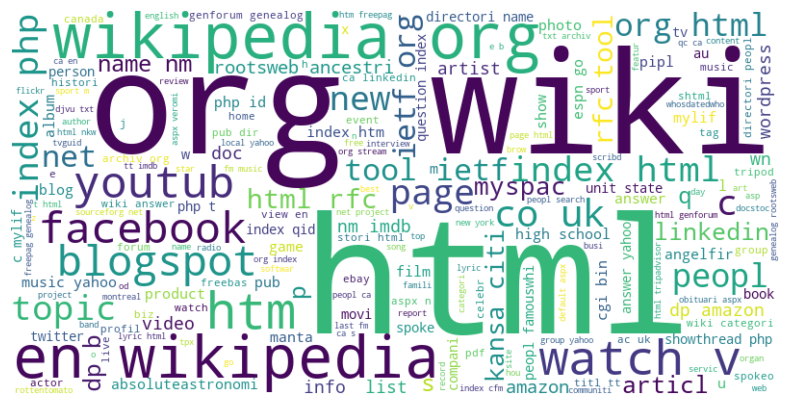

In [28]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_Good_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [29]:
all_bad_text=' '.join(bad_sites['text'].tolist())

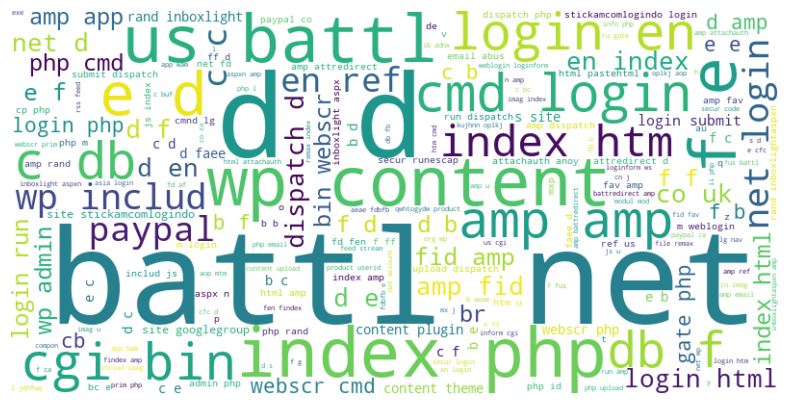

In [30]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_bad_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

In [32]:
cv=CountVectorizer()

In [33]:
features=cv.fit_transform(df.text)

In [34]:
features[:5].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

Data Splitting

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train, x_test, y_train, y_test= train_test_split(features, df.Label, test_size= 0.2)

In [37]:
print(y_train)

482384    good
237094    good
457429    good
240924    good
90468     good
          ... 
342782    good
42896      bad
70333     good
518678     bad
137278     bad
Name: Label, Length: 439476, dtype: object


In [38]:
#Logistics Regression

In [39]:
print(y_train)

482384    good
237094    good
457429    good
240924    good
90468     good
          ... 
342782    good
42896      bad
70333     good
518678     bad
137278     bad
Name: Label, Length: 439476, dtype: object


In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
l_model = LogisticRegression()

In [42]:
l_model.fit(x_train,y_train)

C:\Users\RISHABH KAUSHIK\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [43]:
l_model.score(x_test, y_test)

0.9642577591699281

In [44]:
l_model.score(x_train, y_train)

0.9775664655180261

In [45]:
#Naive Bayes 

In [46]:
from sklearn.naive_bayes import MultinomialNB

In [47]:
mnb = MultinomialNB()

In [48]:
mnb.fit(x_train,y_train)

MultinomialNB()

In [49]:
mnb.score(x_test,y_test)

0.9585601165013198

In [50]:
mnb.score(x_train,y_train)

0.9743899553104152

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
df.head()

,URL,Label,tokens,Stemmed_text,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [53]:
import re

def extract_features(URL):

    url_length = len(URL)

    dots = URL.count('.')

    has_at = 1 if '@' in URL else 0

    has_https = 1 if 'https' in URL else 0

    has_ip = 1 if re.search(r'(([0-9]{1,3}\.){3}[0-9]{1,3})', URL) else 0

    hyphen = URL.count('-')

    return [url_length, dots, has_at, has_https, has_ip, hyphen]

In [54]:
features_2 = df['URL'].apply(lambda x: extract_features(x))

features_2 = pd.DataFrame(features_2.tolist(),
columns=[
'url_length',
'dots',
'has_at',
'https',
'has_ip',
'hyphen'
])

In [55]:
features_2

,url_length,dots,has_at,https,has_ip,hyphen
0,225,6,0,0,0,4
1,81,5,0,0,0,2
2,177,7,0,0,0,1
3,60,6,0,0,0,0
4,116,1,0,0,0,1
...,...,...,...,...,...,...
549341,15,3,0,0,1,0
549342,18,1,0,0,0,1
549343,17,1,0,0,0,1
549344,18,1,0,0,0,1


In [56]:
X = features_2
Y = df['Label']

In [57]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
model = RandomForestClassifier(n_estimators=100)

In [60]:
model.fit(X_train,Y_train)

RandomForestClassifier()

In [61]:
from sklearn.metrics import accuracy_score

In [62]:
pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.669746063529626


In [63]:
model.score(X_train, Y_train)

0.7874741737887848

In [64]:
predict_good=['https://takeuforward.org/interviews/tcs-nqt-coding-sheet-tcs-coding-questions','https://www.googlecareers.in/intern']
predict_bad=['URL16	lingshc.com/old_aol.1.3/?Login=&amp;Lis=10&amp;LigertID=1993745&amp;us=1','https://monkeytype.com/leaderboards?type=allTime&mode=time&mode2=15&language=english&page=1']


In [65]:
predict_good=cv.transform(predict_good)

In [66]:
predict_bad=cv.transform(predict_bad)

In [67]:
l_model.predict(predict_good)

array(['good', 'bad'], dtype=object)

In [68]:
l_model.predict(predict_bad)

array(['bad', 'good'], dtype=object)

In [69]:
from sklearn.metrics import classification_report

In [70]:
print('Classification Report of logistics Regression\n')
print(classification_report(l_model.predict(x_test),y_test,target_names = ['Bad','Good']))

Classification Report of logistics Regression

              precision    recall  f1-score   support

         Bad       0.91      0.97      0.94     29338
        Good       0.99      0.96      0.98     80532

    accuracy                           0.96    109870
   macro avg       0.95      0.96      0.96    109870
weighted avg       0.97      0.96      0.96    109870



In [71]:
#confusion matrix

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [73]:
con_mat = pd.DataFrame(confusion_matrix(l_model.predict(x_test),y_test),
                       columns = ['Predicted: Bad','Predicted: Good'],
                       index = ['Actual: Bad','Actual: Good'])


 CONFUSION MATRIX



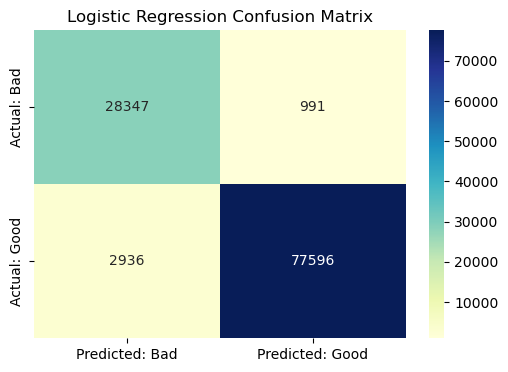

In [110]:
print('\n CONFUSION MATRIX\n')
plt.figure(figsize=(6,4))
sns.heatmap(con_mat, annot=True, fmt='d',cmap='YlGnBu')
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("static/logistic_confusion_matrix.png")

In [75]:
 print('Classification Report of Naive bayes\n')
print(classification_report(mnb.predict(x_test),y_test,target_names = ['Bad','Good']))

Classification Report of Naive bayes

              precision    recall  f1-score   support

         Bad       0.92      0.93      0.93     30752
        Good       0.97      0.97      0.97     79118

    accuracy                           0.96    109870
   macro avg       0.95      0.95      0.95    109870
weighted avg       0.96      0.96      0.96    109870



In [76]:
CON_MNB = pd.DataFrame(confusion_matrix(mnb.predict(x_test),y_test),
                       columns = ['Predicted: Bad','Predicted: Good'],
                       index = ['Actual: Bad','Actual: Good'])


 CONFUSION MATRIX OF NAIVE BAYES ALGO



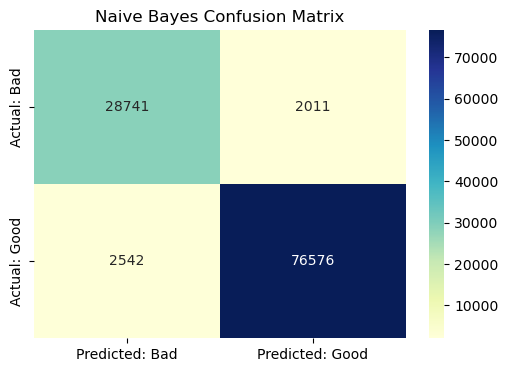

In [111]:
print('\n CONFUSION MATRIX OF NAIVE BAYES ALGO\n')
plt.figure(figsize=(6,4))
sns.heatmap(CON_MNB, annot=True, fmt='d',cmap='YlGnBu')
plt.title("Naive Bayes Confusion Matrix")
plt.savefig("static/mnb_confusion_matrix.png")

In [78]:
print('Classification Report of RANDOM FOREST CLASSIFIER\n')
print(classification_report(model.predict(X_test),Y_test,target_names = ['Bad','Good']))

Classification Report of RANDOM FOREST CLASSIFIER

              precision    recall  f1-score   support

         Bad       0.30      0.82      0.44     11472
        Good       0.97      0.78      0.87     98398

    accuracy                           0.78    109870
   macro avg       0.64      0.80      0.65    109870
weighted avg       0.90      0.78      0.82    109870



In [79]:
CON_RAN = pd.DataFrame(confusion_matrix(model.predict(X_test),Y_test),
                       columns = ['Predicted: Bad','Predicted: Good'],
                       index = ['Actual: Bad','Actual: Good'])


 CONFUSION MATRIX OF RANDOM FOREST CLASSIFIER ALGO



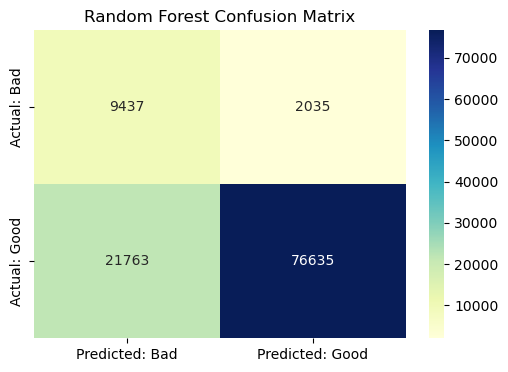

In [112]:
print('\n CONFUSION MATRIX OF RANDOM FOREST CLASSIFIER ALGO\n')
plt.figure(figsize=(6,4))
sns.heatmap(CON_RAN, annot=True, fmt='d',cmap='YlGnBu')
plt.title("Random Forest Confusion Matrix")
plt.savefig("static/Random_confusion_matrix.png")

In [81]:
X_train

,url_length,dots,has_at,https,has_ip,hyphen
146786,29,3,0,0,0,0
480345,51,2,0,0,0,0
232134,36,2,0,0,0,0
427150,120,1,0,0,0,19
183804,32,2,0,0,0,0
...,...,...,...,...,...,...
110268,67,1,0,0,0,1
259178,36,2,0,0,0,1
365838,9,1,0,0,0,0
131932,33,4,0,0,0,0


In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Save Model

In [83]:
import pickle

In [84]:
pickle.dump(l_model, open('logistic_phishing.pkl', 'wb'))

In [85]:
pickle.dump(cv, open('vectorizer.pkl', 'wb'))

In [86]:
pickle.dump(mnb, open('Naive Bayes_phishing.pkl', 'wb'))

In [87]:
pickle.dump(model, open('Random_forest_phishing.pkl', 'wb'))

In [89]:
pickle.dump(con_mat, open('logictic_confusion_matrix.pkl', 'wb'))

In [90]:
pickle.dump(CON_MNB, open('cm_nb.pkl', 'wb'))

In [92]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(x_train, y_train)

print("SVM Accuracy:", svm_model.score(x_test, y_test))

SVM Accuracy: 0.9794484390643488


In [93]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(loss='log_loss')  # logistic regression style
sgd_model.fit(x_train, y_train)

print("SGD Accuracy:", sgd_model.score(x_test, y_test))

SGD Accuracy: 0.928852279967234


In [113]:
print("Logistic:", l_model.score(x_test, y_test))
print("SVM:", svm_model.score(x_test, y_test))
print("Naive Bayes:", mnb.score(x_test, y_test))
print("SGD:", sgd_model.score(x_test, y_test))

Logistic: 0.9642577591699281
SVM: 0.9794484390643488
Naive Bayes: 0.9585601165013198
SGD: 0.928852279967234


In [96]:
pickle.dump(svm_model, open('svm_model.pkl', 'wb'))

In [97]:
pickle.dump(sgd_model, open('sgd_model.pkl', 'wb'))

In [99]:
CON_SVM = pd.DataFrame(confusion_matrix(svm_model.predict(x_test),y_test),
                       columns = ['Predicted: Bad','Predicted: Good'],
                       index = ['Actual: Bad','Actual: Good'])


 CONFUSION MATRIX OF linear SVM ALGO



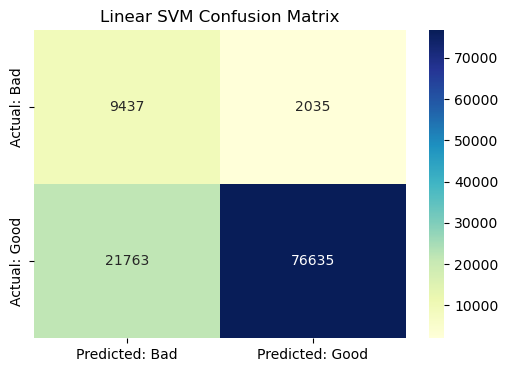

In [109]:
print('\n CONFUSION MATRIX OF linear SVM ALGO\n')
plt.figure(figsize=(6,4))
sns.heatmap(CON_RAN, annot=True, fmt='d',cmap='YlGnBu')
plt.title("Linear SVM Confusion Matrix")
plt.savefig("static/SVM_confusion_matrix.png")


 CONFUSION MATRIX of SGD ALGO



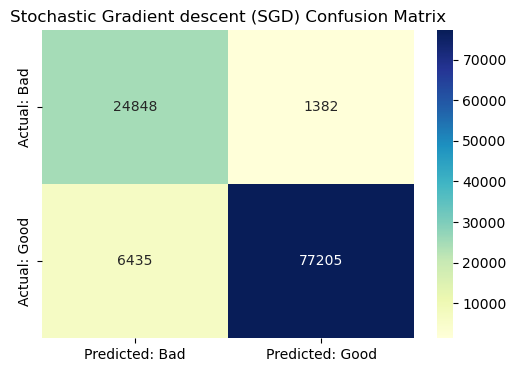

In [108]:
CON_SGD = pd.DataFrame(confusion_matrix(sgd_model.predict(x_test),y_test),
                       columns = ['Predicted: Bad','Predicted: Good'],
                       index = ['Actual: Bad','Actual: Good'])
print('\n CONFUSION MATRIX of SGD ALGO\n')
plt.figure(figsize=(6,4))
sns.heatmap(CON_SGD, annot=True, fmt='d',cmap='YlGnBu')
plt.title("Stochastic Gradient descent (SGD) Confusion Matrix")
plt.savefig("static/SGD_confusion_matrix.png")

In [114]:
import sklearn
print(sklearn.__version__)

1.5.1
